In [3]:
import torch
import torch.nn as nn
import os
from transformers import AutoModel, AutoTokenizer
from transformers import BertModel, BertTokenizer
import random
from scipy.interpolate import interp1d
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import roc_auc_score,roc_curve
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import KFold
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
import random
import matplotlib.pyplot as plt
from torch.utils.data.sampler import SubsetRandomSampler
import numpy as np
import torch
import csv
import pandas as pd
import pickle


In [4]:
#Model settings
batch_size = 32  # Setting batchsize
learning_rates=0.000065 # Setting learning rates
model_name="esm2_12"#Select different versions of the ESM2 model: esm2_6,esm_12,esm_30.

In [5]:
#Dataset definitions

class MyDataset(Dataset):
    def __init__(self, file):
        self.sequence, self.label = self.read_file(file)
        self.sequence_protbert=self.add_space_between_characters(self.sequence)

    def read_file(self,file_path):
        sequences = []
        labels = []
        with open(file_path, 'r', newline='') as csv_file:
            csv_reader = csv.reader(csv_file)
            next(csv_reader, None)  
            data = list(csv_reader)
            random.seed(42)
            random.shuffle(data)  
            for row in data:
                sequences.append(row[1])
                labels.append(row[2])
        return sequences, labels
    
    def add_space_between_characters(self,input_list):
        new_list = []
        for element in input_list:
            new_element = ' '.join(element)
            new_list.append(new_element)
        return new_list

    def __len__(self):
        return len(self.sequence)

    def __getitem__(self, index):
        sample=self.sequence[index]
        sample_protbert=self.sequence_protbert[index]
        label=int(self.label[index])
        return sample, label, sample_protbert

In [6]:
# Read the training set

train_file = 'E:\\LLM+XWT\\XWT数据\\Umami-BERT-UMP789\\1_1-data.csv'  
train_dataset = MyDataset(train_file)
train_dataloader = DataLoader(train_dataset, batch_size=batch_size)

In [7]:
#Define the esm family of models

class MyModel(nn.Module):
    def __init__(self,):
        super(MyModel, self).__init__()
        if model_name=="esm2_30":
            self.model = AutoModel.from_pretrained("facebook/esm2_t30_150M_UR50D")
            self.tokenizer = AutoTokenizer.from_pretrained("facebook/esm2_t30_150M_UR50D")
            self.layer=640
        elif model_name=="esm2_12":
            self.model = AutoModel.from_pretrained("facebook/esm2_t12_35M_UR50D")
            self.tokenizer = AutoTokenizer.from_pretrained("facebook/esm2_t12_35M_UR50D")
            self.layer=480
        elif model_name=="esm2_6":
            self.model = AutoModel.from_pretrained("facebook/esm2_t6_8M_UR50D")
            self.tokenizer = AutoTokenizer.from_pretrained("facebook/esm2_t6_8M_UR50D")
            self.layer=320
        self.fc2 = nn.Linear(self.layer, 2) 

    def forward(self, inputs,inputs2):
        inputs = self.tokenizer(inputs, padding=True, truncation=True, return_tensors="pt")
        input_ids = inputs["input_ids"].to(device)
        attention_mask = inputs["attention_mask"].to(device)
        outputs = self.model(input_ids=input_ids, attention_mask=attention_mask)
        pooler_output1 = outputs.pooler_output   
        x=self.fc2(pooler_output1)
        return x

In [8]:
#Model loading and setting

device = torch.device("cpu") 
random_seed = 42
random.seed(random_seed)
np.random.seed(random_seed)
torch.manual_seed(random_seed)
torch.cuda.manual_seed(random_seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
model = MyModel()
model.to(device)#Model loading
criterion = nn.CrossEntropyLoss()
loss_all=99999
best_auc=0
all_fpr = []
all_tpr = []
all_aucs = []

Some weights of EsmModel were not initialized from the model checkpoint at facebook/esm2_t12_35M_UR50D and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [9]:
# Five-fold cross-validation

kf = KFold(n_splits=5, shuffle=False)
for fold, (train_indices, valid_indices) in enumerate(kf.split(train_dataset)):
    best_auc=0
    best_acc=0
    train_sampler = SubsetRandomSampler(train_indices)
    valid_sampler = SubsetRandomSampler(valid_indices)
    best_fpr=np.array([])
    best_tpr=np.array([])
    train_dataloader = DataLoader(train_dataset, batch_size=batch_size, sampler=train_sampler)
    valid_dataloader = DataLoader(train_dataset, batch_size=batch_size, sampler=valid_sampler)
    model = MyModel()
    model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.000065)
    item=0
    for epoch in range(50):
        item=item+1
        print(item)
        for batch_data, batch_labels, batch_data_protbert in train_dataloader:
            model.train()
            batch_labels = batch_labels.to(device)
            outputs = model(batch_data,batch_data_protbert)
            loss = criterion(outputs, batch_labels)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
        all_labels = []
        all_scores = []
        model.eval()      
        for batch_data, batch_labels, batch_data_protbert in valid_dataloader:
            batch_labels = batch_labels.to(device)
            outputs = model(batch_data,batch_data_protbert)
            probabilities = nn.functional.softmax(outputs, dim=1)
            scores = probabilities[:, 1]  

            all_labels.extend(batch_labels.tolist())
            all_scores.extend(scores.tolist())
        fpr, tpr, _ = roc_curve(all_labels, all_scores)
        auc = roc_auc_score(all_labels, all_scores)
        correct_predictions = (np.array(all_scores) >= 0.5).astype(int)
        print(auc)
        if auc>best_auc:
            best_fpr=fpr
            best_tpr=tpr
            best_auc=auc
    all_fpr.append(best_fpr)
    all_tpr.append(best_tpr)
    all_aucs.append(best_auc)
    print(f"Fold {fold + 1}: AUC = {best_auc:.6f}")

Some weights of EsmModel were not initialized from the model checkpoint at facebook/esm2_t12_35M_UR50D and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.


1
0.9569011105235325
2
0.9378635642517187
3
0.9619249074563723
4
0.9698572184029615
5
0.9637757800105764
6
0.9717080909571656
7
0.9613960867265997
8
0.9531993654151244
9
0.976467477525119
10
0.9664198836594393
11
0.959016393442623
12
0.960867265996827
13
0.9569011105235325
14
0.939978847170809
15
0.9674775251189847
16
0.9579587519830778
17
0.9566367001586462
18
0.9592808038075092
19
0.9606028556319407
20
0.9619249074563723
21
0.9613960867265996
22
0.9606028556319407
23
0.9603384452670545
24
0.9603384452670545
25
0.9608672659968271
26
0.9606028556319407
27
0.9603384452670545
28
0.9602062400846113
29
0.9603384452670546
30
0.9603384452670546
31
0.9603384452670546
32
0.959809624537282
33
0.9598096245372819
34
0.9598096245372819
35
0.9595452141723957
36
0.959016393442623
37
0.959016393442623
38
0.9587519830777368
39
0.959016393442623
40
0.9588841882601797
41
0.9584875727128503
42
0.9582231623479641
43
0.9584875727128503
44
0.9576943416181914
45
0.9574299312533052
46
0.9571655208884189
47
0.

Some weights of EsmModel were not initialized from the model checkpoint at facebook/esm2_t12_35M_UR50D and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.


1
0.9626588983050848
2
0.9615995762711864
3
0.9690148305084746
4
0.9676906779661016
5
0.951271186440678
6
0.9576271186440678
7
0.9592161016949152
8
0.9560381355932204
9
0.9629237288135593
10
0.9615995762711864
11
0.9520656779661016
12
0.9420021186440678
13
0.9621292372881356
14
0.963188559322034
15
0.9629237288135594
16
0.958156779661017
17
0.9661016949152542
18
0.9698093220338982
19
0.9708686440677966
20
0.9708686440677967
21
0.9711334745762712
22
0.9706038135593219
23
0.9703389830508474
24
0.9698093220338982
25
0.9692796610169491
26
0.9698093220338984
27
0.9698093220338984
28
0.9698093220338984
29
0.9702065677966102
30
0.9700741525423728
31
0.9700741525423728
32
0.9700741525423728
33
0.9703389830508474
34
0.970603813559322
35
0.970603813559322
36
0.970603813559322
37
0.970603813559322
38
0.970603813559322
39
0.970603813559322
40
0.970603813559322
41
0.970603813559322
42
0.9707362288135594
43
0.9707362288135594
44
0.9708686440677966
45
0.9707362288135594
46
0.9708686440677966
47
0.970

Some weights of EsmModel were not initialized from the model checkpoint at facebook/esm2_t12_35M_UR50D and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.


1
0.9267057569296375
2
0.947228144989339
3
0.9528251599147122
4
0.9520255863539446
5
0.9640191897654584
6
0.962953091684435
7
0.9456289978678037
8
0.9637526652452025
9
0.9616204690831557
10
0.9586886993603412
11
0.9498933901918977
12
0.9448294243070362
13
0.9440298507462687
14
0.9530916844349681
15
0.9568230277185501
16
0.9604211087420043
17
0.950959488272921
18
0.9573560767590619
19
0.9578891257995736
20
0.9562899786780383
21
0.9554904051172708
22
0.954957356076759
23
0.9546908315565031
24
0.9544243070362474
25
0.954957356076759
26
0.9546908315565032
27
0.9544243070362474
28
0.9544243070362474
29
0.9538912579957356
30
0.9536247334754797
31
0.9533582089552239
32
0.9533582089552238
33
0.9533582089552238
34
0.9538912579957355
35
0.9538912579957355
36
0.9541577825159915
37
0.9541577825159914
38
0.9541577825159914
39
0.9544243070362474
40
0.9544243070362473
41
0.9546908315565031
42
0.9546908315565031
43
0.9546908315565031
44
0.9546908315565031
45
0.9546908315565031
46
0.9541577825159915
47

Some weights of EsmModel were not initialized from the model checkpoint at facebook/esm2_t12_35M_UR50D and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.


1
0.9473823373876257
2
0.9611316763617133
3
0.9674775251189847
4
0.9643046007403491
5
0.9606028556319408
6
0.9537281861448969
7
0.9677419354838709
8
0.9621893178212586
9
0.9603384452670545
10
0.9534637757800105
11
0.9539925965097832
12
0.9537281861448969
13
0.9542570068746695
14
0.9561078794288737
15
0.9561078794288737
16
0.9571655208884189
17
0.9569011105235324
18
0.9569011105235324
19
0.9569011105235325
20
0.9569011105235325
21
0.9566367001586462
22
0.9566367001586462
23
0.9569011105235325
24
0.9569011105235325
25
0.9572977260708619
26
0.9574299312533051
27
0.9574299312533051
28
0.9571655208884189
29
0.9569011105235325
30
0.9569011105235325
31
0.9569011105235325
32
0.9569011105235325
33
0.9569011105235325
34
0.9569011105235325
35
0.9569011105235325
36
0.9569011105235325
37
0.9566367001586462
38
0.9569011105235325
39
0.9566367001586462
40
0.9566367001586462
41
0.9566367001586463
42
0.9570333157059756
43
0.9570333157059756
44
0.9571655208884189
45
0.9571655208884189
46
0.95716552088841

Some weights of EsmModel were not initialized from the model checkpoint at facebook/esm2_t12_35M_UR50D and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.


1
0.8726045883940621
2
0.9079622132253712
3
0.8955465587044535
4
0.9206477732793523
5
0.9198380566801619
6
0.8871794871794872
7
0.9322537112010796
8
0.9292847503373819
9
0.9276653171390014
10
0.9263157894736842
11
0.9238866396761134
12
0.9252361673414304
13
0.925506072874494
14
0.9255060728744939
15
0.9257759784075573
16
0.9265856950067477
17
0.9265856950067476
18
0.9265856950067477
19
0.926450742240216
20
0.9260458839406208
21
0.9257759784075573
22
0.9260458839406207
23
0.9260458839406207
24
0.9257759784075573
25
0.9257759784075573
26
0.9257759784075573
27
0.9257759784075574
28
0.9255060728744939
29
0.9255060728744939
30
0.9255060728744939
31
0.9255060728744939
32
0.9255060728744939
33
0.9255060728744939
34
0.9255060728744939
35
0.9255060728744939
36
0.9257759784075574
37
0.9257759784075574
38
0.9257759784075574
39
0.9257759784075574
40
0.925910931174089
41
0.9260458839406207
42
0.9257759784075574
43
0.9260458839406207
44
0.9260458839406208
45
0.9260458839406207
46
0.9260458839406208


In [10]:
# 步骤 1: 解耦保存数据 (Decoupling: Save Data)
# ---------------------------------------------------------
save_dir = 'E:/LLM+XWT/实验结果/Five_fold_esm_2_12_XWT/'
if not os.path.exists(save_dir):
    os.makedirs(save_dir)

data_save_path = os.path.join(save_dir, '5_fold_data.pkl')
with open(data_save_path, 'wb') as f:
    pickle.dump({'all_fpr': all_fpr, 'all_tpr': all_tpr, 'all_aucs': all_aucs}, f)

print(f"Data saved to {data_save_path}. You can load this next time to skip training.")

Data saved to E:/LLM+XWT/实验结果/Five_fold_esm_2_12_XWT/5_fold_data.pkl. You can load this next time to skip training.


In [11]:
# --- 全局字体与绘图设置 (Arial, Bold, Size 22) ---
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial']
plt.rcParams['font.weight'] = 'bold'
plt.rcParams['axes.labelweight'] = 'bold' # 坐标轴标签加粗
plt.rcParams['font.size'] = 22

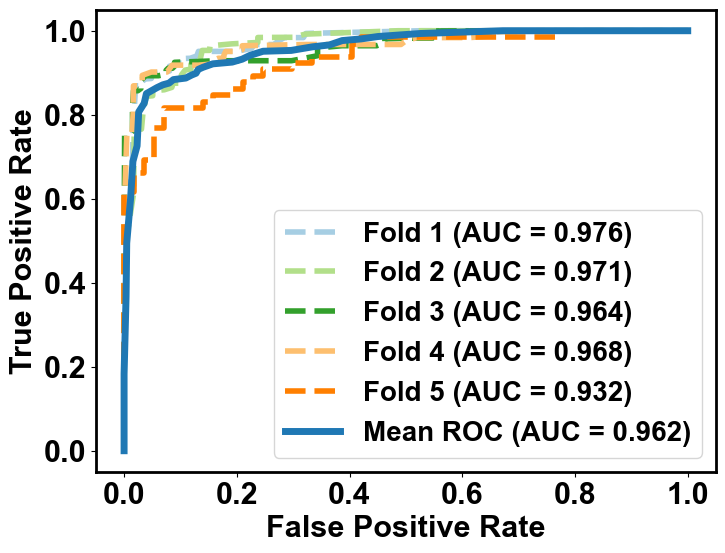

AUC for each fold: [np.float64(0.976467477525119), np.float64(0.9711334745762712), np.float64(0.9640191897654584), np.float64(0.9677419354838709), np.float64(0.9322537112010796)]
Mean AUC: 0.9623231577103599
Image saved to E:/LLM+XWT/实验结果/Five_fold_esm_2_12_XWT/5_fold_roc_refined.png


In [12]:
#Drawing roc diagrams
# ---------------------------------------------------------
# 步骤 2: 绘图 (Plotting with custom styles)
# ---------------------------------------------------------
# 如果需要单独运行绘图，可以从这里开始，并加载上面的pkl文件
# with open(data_save_path, 'rb') as f:
#     data = pickle.load(f)
#     all_fpr = data['all_fpr']
#     all_tpr = data['all_tpr']
#     all_aucs = data['all_aucs']

# 指定配色
custom_colors = ["#A6CEE3", "#B2DF8A", "#33A02C", "#FDBF6F", "#FF7F00", "#FB9A99", "#1F78B4"]

plt.figure(figsize=(8, 6)) # 稍微调大一点画布以适应大字体

# 插值平滑处理 (保持原逻辑)
max_length = max(len(fpr) for fpr in all_fpr)
new_all_fpr = []
new_all_tpr = []
for fpr, tpr in zip(all_fpr, all_tpr):
    f = interp1d(np.linspace(0, 1, len(fpr)), fpr)
    t = interp1d(np.linspace(0, 1, len(tpr)), tpr)
    new_fpr = f(np.linspace(0, 1, max_length))
    new_tpr = t(np.linspace(0, 1, max_length))
    new_all_fpr.append(new_fpr)
    new_all_tpr.append(new_tpr)
all_fpr = new_all_fpr
all_tpr = new_all_tpr

# 绘制每一折
for i in range(len(all_fpr)):
    color_idx = i % len(custom_colors)
    plt.plot(all_fpr[i], all_tpr[i], 
             linestyle='--', 
             lw=4, # 线条加粗
             color=custom_colors[color_idx],
             label=f'Fold {i + 1} (AUC = {all_aucs[i]:.3f})')

# 绘制平均曲线
mean_fpr = np.mean(all_fpr, axis=0)
mean_tpr = np.mean(all_tpr, axis=0)
mean_color = custom_colors[-1] # 使用最后一个粉色或者您指定的颜色

plt.plot(mean_fpr, mean_tpr, 
         color=mean_color, 
         linestyle='-', 
         lw=5, # 平均线更粗一点
         label='Mean ROC (AUC = {:.3f})'.format(np.mean(all_aucs)))

# 设置图形属性
plt.xlim([-0.05, 1.05])
plt.ylim([-0.05, 1.05])

plt.xlabel('False Positive Rate', fontsize=22, fontweight='bold')
plt.ylabel('True Positive Rate', fontsize=22, fontweight='bold')

# 刻度字体设置
plt.xticks(fontsize=22, fontweight='bold')
plt.yticks(fontsize=22, fontweight='bold')

# 图例设置 (Arial, Bold, 20 - 稍微小一点以免遮挡，或者也用22)
# 注意：matplotlib图例自动继承全局字体，但为了保险起见可以强制指定
plt.legend(loc="lower right", fontsize=20, prop={'family': 'Arial', 'weight': 'bold', 'size': 20})

# 加粗边框 (可选，为了学术风更强)
ax = plt.gca()
ax.spines['bottom'].set_linewidth(2)
ax.spines['left'].set_linewidth(2)
ax.spines['top'].set_linewidth(2)
ax.spines['right'].set_linewidth(2)

# 保存图片
image_save_path = os.path.join(save_dir, '5_fold_roc_refined.png')
plt.savefig(image_save_path, dpi=600, bbox_inches='tight')
plt.show()

print("AUC for each fold:", all_aucs)
print("Mean AUC:", np.mean(all_aucs))
print(f"Image saved to {image_save_path}")